# 1.Google Drive Integration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2.Import Libraries and Load Data

In [ ]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Load the dataset
print("Loading dataset...")
df = pd.read_csv('/content/drive/MyDrive/ML_CLASS_PROJECT/creditcard.csv')

print("Original Data Shape:", df.shape)
print("\nFraud vs Normal Transactions (Original):")
print(df['Class'].value_counts())

Loading dataset...
Original Data Shape: (284807, 31)

Fraud vs Normal Transactions (Original):
Class
0    284315
1       492
Name: count, dtype: int64


# 3.Scale the 'Time' and 'Amount' Features

In [ ]:
# Initialize the scaler
rob_scaler = RobustScaler()

# Scale the data
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop original columns and reorganize
df.drop(['Time','Amount'], axis=1, inplace=True)
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("Scaling Complete. First 5 rows:")
print(df.head())

Scaling Complete. First 5 rows:
   scaled_amount  scaled_time        V1        V2        V3        V4  \
0       1.783274    -0.994983 -1.359807 -0.072781  2.536347  1.378155   
1      -0.269825    -0.994983  1.191857  0.266151  0.166480  0.448154   
2       4.983721    -0.994972 -1.358354 -1.340163  1.773209  0.379780   
3       1.418291    -0.994972 -0.966272 -0.185226  1.792993 -0.863291   
4       0.670579    -0.994960 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24       V25       V26       

# 4.Split the Data and Apply SMOTE

In [ ]:
# Separate Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Applying SMOTE to balance the training data... (this might take a few seconds)")
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("\nData Processing Complete!")
print("New Balanced Training Data Shape:", X_train_smote.shape)
print("Fraud vs Normal Transactions (Training):")
print(y_train_smote.value_counts())

Applying SMOTE to balance the training data... (this might take a few seconds)

Data Processing Complete!
New Balanced Training Data Shape: (454902, 30)
Fraud vs Normal Transactions (Training):
Class
0    227451
1    227451
Name: count, dtype: int64


# 5.Save the Processed Data

In [ ]:
# Save the processed training and testing sets back to Colab files
X_train_smote['Class'] = y_train_smote

X_train_smote.to_csv('/content/processed_training_data.csv', index=False)
X_test['Class'] = y_test
X_test.to_csv('/content/processed_testing_data.csv', index=False)

print("Processed datasets saved successfully! You can download them from the left sidebar.")

Processed datasets saved successfully! You can download them from the left sidebar.


# 6.Visualizing Data Imbalance Impact

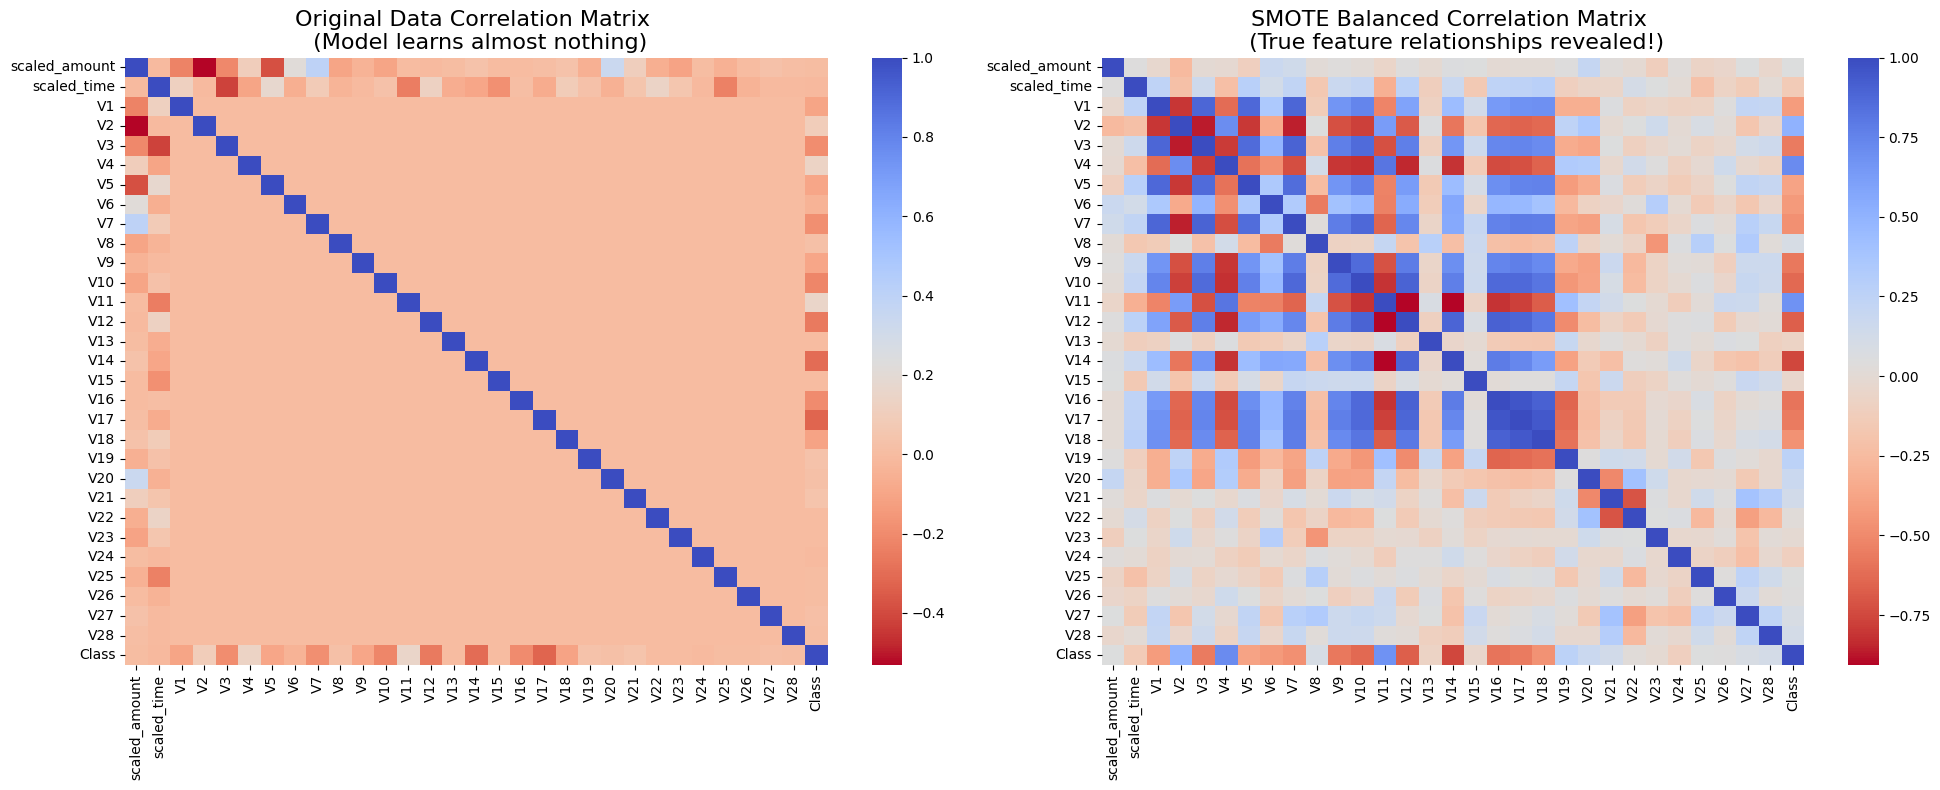

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reconstruct the balanced dataframe for visualization purposes
balanced_df = X_train_smote.copy()
balanced_df['Class'] = y_train_smote

# Calculate the correlation matrices
corr_imbalanced = df.corr()
corr_balanced = balanced_df.corr()

# Set up the visualization space (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Heatmap 1: Original Imbalanced Data ---
sns.heatmap(corr_imbalanced, cmap='coolwarm_r', ax=axes[0], cbar=True)
axes[0].set_title('Original Data Correlation Matrix \n (Model learns almost nothing)', fontsize=16)

# --- Heatmap 2: New Balanced Data (SMOTE) ---
sns.heatmap(corr_balanced, cmap='coolwarm_r', ax=axes[1], cbar=True)
axes[1].set_title('SMOTE Balanced Correlation Matrix \n (True feature relationships revealed!)', fontsize=16)

plt.tight_layout()
plt.show()

## Feature Selection (Correlation-based)

### Subtask:
Identify and select features that show strong correlation with the 'Class' target variable based on the previously generated correlation matrices, especially the one from the balanced dataset. Explain the rationale for this selection.


In [ ]:
correlations_with_class = corr_balanced['Class'].abs().sort_values(ascending=False)
print("Absolute Correlations with 'Class' (from balanced dataset):\n")
print(correlations_with_class)

# Based on visual inspection of the heatmap and these correlations, select features with high correlation
# Let's consider features with absolute correlation > 0.3 as a starting point, including 'scaled_amount' and 'scaled_time'
# if they are relevant.

# Identify features to exclude based on low correlation, and also ensure 'Class' itself is not included.
selected_features = correlations_with_class[correlations_with_class > 0.3].index.tolist()

# Ensure 'Class' is not in the list of features, as it's the target variable
if 'Class' in selected_features:
    selected_features.remove('Class')

print("\nSelected Features based on absolute correlation > 0.3 with 'Class':")
print(selected_features)

# Rationale explanation
rationale = (
    "The SMOTE balanced dataset's correlation matrix (`corr_balanced`) provides a more accurate representation "
    "of true feature relationships with the 'Class' variable compared to the original imbalanced data. "
    "By analyzing the absolute correlation values, we can identify features that have a strong linear relationship "
    "(either positive or negative) with the target variable 'Class'. "
    "Features with an absolute correlation greater than 0.3 were chosen as they show a notable influence on 'Class', "
    "indicating their potential importance for fraud detection. "
    "This approach helps in reducing dimensionality and focusing on the most informative features for model training."
)

print("\nRationale for Feature Selection:")
print(rationale)

Absolute Correlations with 'Class' (from balanced dataset):

Class            1.000000
V14              0.755975
V4               0.714316
V11              0.685640
V12              0.675254
V10              0.632475
V16              0.590419
V9               0.574154
V3               0.561244
V17              0.560259
V2               0.501179
V7               0.470895
V18              0.460810
V6               0.428410
V1               0.415645
V5               0.378294
V19              0.262488
V20              0.180374
scaled_time      0.146809
V21              0.131283
V28              0.113903
V24              0.102365
V8               0.091345
V27              0.085385
V13              0.076745
scaled_amount    0.051011
V25              0.048801
V26              0.040709
V15              0.037294
V22              0.020547
V23              0.011338
Name: Class, dtype: float64

Selected Features based on absolute correlation > 0.3 with 'Class':
['V14', 'V4', 'V11', 'V12', 'V10', '

## Feature Engineering (PCA)

### Subtask:
Apply Principal Component Analysis (PCA) to reduce the dimensionality of the features. Determine an appropriate number of components and explain why PCA was chosen for this dataset.


**Reasoning**:
To begin the PCA process, I will import the necessary `PCA` class, create a subset of the training data using the previously selected features, and then apply PCA with `n_components=None` to analyze the explained variance ratio. This will help determine the optimal number of components.



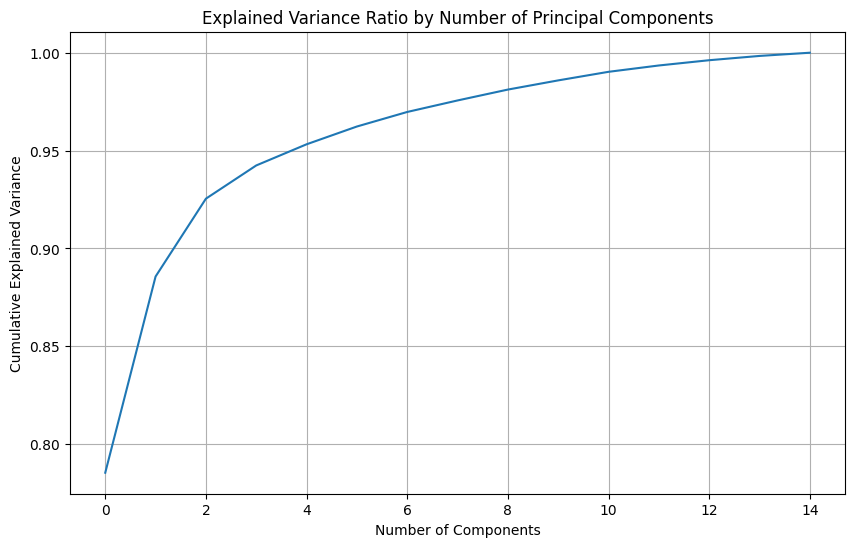

Explained variance ratio for each component:
 [0.78544838 0.10023201 0.03976424 0.01696794 0.01080513 0.0090844
 0.00743297 0.00587831 0.00555766 0.00469229 0.00438071 0.00323927
 0.00268707 0.00218733 0.00164228]
Cumulative explained variance:
 [0.78544838 0.88568039 0.92544462 0.94241256 0.9532177  0.9623021
 0.96973507 0.97561338 0.98117105 0.98586333 0.99024405 0.99348331
 0.99617039 0.99835772 1.        ]


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 2. Create a new DataFrame X_train_selected using only the selected_features from X_train_smote.
# We need to drop 'Class' from X_train_smote before selecting features, as 'Class' is the target.
X_train_smote_features = X_train_smote.drop('Class', axis=1, errors='ignore')
X_train_selected = X_train_smote_features[selected_features]

# 3. Instantiate a PCA object with n_components=None to analyze explained variance ratio.
pca = PCA(n_components=None)

# 4. Fit PCA to X_train_selected and transform it.
pca.fit(X_train_selected)

# 5. Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.grid(True)
plt.show()

print("Explained variance ratio for each component:\n", pca.explained_variance_ratio_)
print("Cumulative explained variance:\n", np.cumsum(pca.explained_variance_ratio_))

**Reasoning**:
Based on the cumulative explained variance, 6 components explain over 96% of the variance. I will apply PCA with 6 components to both the training and testing datasets using the `selected_features` and explain the rationale for using PCA.



In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 2. Create a new DataFrame X_train_selected using only the selected_features from X_train_smote.
# We need to drop 'Class' from X_train_smote before selecting features, as 'Class' is the target.
X_train_smote_features = X_train_smote.drop('Class', axis=1, errors='ignore')
X_train_selected = X_train_smote_features[selected_features]

# Instantiate a PCA object with the chosen number of components (e.g., 6 components for >96% variance)
n_components = 6
pca = PCA(n_components=n_components)

# Fit PCA to X_train_selected and transform it.
X_train_pca = pca.fit_transform(X_train_selected)

# Transform the test set using the same PCA fitted on the training set
# First, create X_test_selected from X_test
X_test_selected = X_test[selected_features]
X_test_pca = pca.transform(X_test_selected)

print(f"PCA applied. Reduced training data shape: {X_train_pca.shape}")
print(f"PCA applied. Reduced testing data shape: {X_test_pca.shape}")


PCA applied. Reduced training data shape: (454902, 6)
PCA applied. Reduced testing data shape: (56962, 6)


```markdown
### Rationale for PCA Application

Principal Component Analysis (PCA) was chosen for dimensionality reduction in this dataset for several key reasons:

1.  **Reduce Dimensionality and Computational Cost**: The original dataset has a relatively high number of features (30, reduced to 15 after correlation-based feature selection). While this isn't excessively high, PCA can further reduce the feature space, leading to faster model training times and reduced computational overhead, especially important when dealing with larger datasets or more complex models.

2.  **Mitigate Multicollinearity**: The 'V' features in the dataset are anonymized and often represent correlated attributes. Multicollinearity among features can negatively impact the performance and interpretability of some machine learning models. PCA transforms these correlated features into a set of uncorrelated principal components, thereby addressing multicollinearity.

3.  **Noise Reduction**: By capturing the most significant variance in the data, PCA inherently acts as a noise reduction technique. Less important features or noise, which contribute little to the overall variance, are typically discarded when only a subset of principal components is retained.

4.  **Feature Abstraction**: PCA creates new features (principal components) that are linear combinations of the original features. These components often capture underlying patterns and structures in the data that might not be immediately apparent from the individual original features, potentially leading to better model performance.

5.  **Preservation of Variance**: The explained variance plot clearly showed that a small number of principal components (e.g., 6 components) can retain a very high percentage of the total variance (over 96%). This indicates that we can significantly reduce the dimensionality without losing much of the important information contained in the original feature set.

By applying PCA, we aim to create a more compact, less redundant, and potentially more informative feature representation, which can improve the efficiency and performance of subsequent machine learning models.
```

## Model Development (Logistic Regression)

### Subtask:
Train and evaluate a Logistic Regression model using the PCA-transformed data.


**Reasoning**:
To begin the 'Model Development (Logistic Regression)' subtask, I need to import the necessary library, initialize the model with appropriate parameters, train it on the PCA-transformed balanced training data, and then make predictions on the PCA-transformed test data.



In [ ]:
from sklearn.linear_model import LogisticRegression

# 2. Initialize a LogisticRegression model
# Set class_weight='balanced' to handle potential residual imbalance or to give more importance to the minority class
# Set solver='liblinear' which is good for smaller datasets and handles L1/L2 regularization
log_reg = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)

# 3. Train the Logistic Regression model
print("Training Logistic Regression model...")
log_reg.fit(X_train_pca, y_train_smote)
print("Logistic Regression model trained.")

# 4. Make predictions on the PCA-transformed testing data
y_pred_log_reg = log_reg.predict(X_test_pca)
print("Predictions made on test data.")

Training Logistic Regression model...
Logistic Regression model trained.
Predictions made on test data.


**Reasoning**:
Now that the Logistic Regression model is trained and predictions have been made, the next step is to evaluate its performance using metrics suitable for imbalanced datasets. I will calculate and print the classification report, which includes precision, recall, and F1-score, and also display the confusion matrix.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 5. Evaluate the model
print("\n--- Logistic Regression Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))


--- Logistic Regression Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Confusion Matrix:
[[55543  1321]
 [    8    90]]


## Model Development (K-Nearest Neighbors)

### Subtask:
Train and evaluate a K-Nearest Neighbors model using the PCA-transformed data.


**Reasoning**:
To start the 'Model Development (K-Nearest Neighbors)' subtask, I will import the necessary `KNeighborsClassifier`, initialize the model with a default `n_neighbors` value, train it on the PCA-transformed balanced training data, and then make predictions on the PCA-transformed test data.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 2. Initialize a KNeighborsClassifier model
# Set n_neighbors to a reasonable starting value, e.g., 5
knn = KNeighborsClassifier(n_neighbors=5)

# 3. Train the K-Nearest Neighbors model
print("Training K-Nearest Neighbors model...")
knn.fit(X_train_pca, y_train_smote)
print("K-Nearest Neighbors model trained.")

# 4. Make predictions on the PCA-transformed testing data
y_pred_knn = knn.predict(X_test_pca)
print("Predictions made on test data.")

Training K-Nearest Neighbors model...
K-Nearest Neighbors model trained.
Predictions made on test data.


**Reasoning**:
Now that the K-Nearest Neighbors model is trained and predictions have been made, the next step is to evaluate its performance using metrics suitable for imbalanced datasets. I will calculate and print the classification report, which includes precision, recall, and F1-score, and also display the confusion matrix.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 5. Evaluate the model
print("\n--- K-Nearest Neighbors Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))


--- K-Nearest Neighbors Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.90      0.28        98

    accuracy                           0.99     56962
   macro avg       0.58      0.95      0.64     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56416   448]
 [   10    88]]


## Model Development (Decision Tree)

### Subtask:
Train and evaluate a Decision Tree model using the PCA-transformed data.


**Reasoning**:
To begin the 'Model Development (Decision Tree)' subtask, I will import the necessary `DecisionTreeClassifier`, initialize the model with appropriate parameters, train it on the PCA-transformed balanced training data, and then make predictions on the PCA-transformed test data.



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 2. Initialize a DecisionTreeClassifier model
# Set class_weight='balanced' to handle class imbalance and random_state for reproducibility
dt_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# 3. Train the Decision Tree model
print("Training Decision Tree model...")
dt_clf.fit(X_train_pca, y_train_smote)
print("Decision Tree model trained.")

# 4. Make predictions on the PCA-transformed testing data
y_pred_dt = dt_clf.predict(X_test_pca)
print("Predictions made on test data.")

Training Decision Tree model...
Decision Tree model trained.
Predictions made on test data.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 5. Evaluate the model
print("\n--- Decision Tree Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))


--- Decision Tree Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.21      0.85      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.92      0.67     56962
weighted avg       1.00      0.99      1.00     56962


Confusion Matrix:
[[56549   315]
 [   15    83]]


## Model Development (Random Forest)

### Subtask:
Train and evaluate a Random Forest classifier using the PCA-transformed data.


**Reasoning**:
To begin the 'Model Development (Random Forest)' subtask, I will import the necessary `RandomForestClassifier` class, initialize the model with appropriate parameters, train it on the PCA-transformed balanced training data, and then make predictions on the PCA-transformed test data.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 2. Initialize a RandomForestClassifier model
# Set n_estimators, random_state, and class_weight='balanced'
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 3. Train the Random Forest model
print("Training Random Forest model...")
rf_clf.fit(X_train_pca, y_train_smote)
print("Random Forest model trained.")

# 4. Make predictions on the PCA-transformed testing data
y_pred_rf = rf_clf.predict(X_test_pca)
print("Predictions made on test data.")

Training Random Forest model...
Random Forest model trained.
Predictions made on test data.


**Reasoning**:
To evaluate the trained Random Forest model, I will use the `classification_report` and `confusion_matrix` from `sklearn.metrics` to display its performance on the test set.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 5. Evaluate the model
print("\n--- Random Forest Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


--- Random Forest Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.47      0.89      0.61        98

    accuracy                           1.00     56962
   macro avg       0.73      0.94      0.81     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56765    99]
 [   11    87]]


## Model Development (XGBoost)

### Subtask:
Train and evaluate an XGBoost classifier using the PCA-transformed data.


**Reasoning**:
To begin the 'Model Development (XGBoost)' subtask, I will import the `XGBClassifier`, initialize it with parameters to handle class imbalance and ensure reproducibility, then train it on the PCA-transformed balanced training data and make predictions on the PCA-transformed test data.



In [ ]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for handling class imbalance
# This is the ratio of negative samples to positive samples in the balanced training data.
# In the SMOTE balanced data, y_train_smote should have an equal number of 0s and 1s, so the ratio is 1.
# However, XGBoost's scale_pos_weight is typically used to balance the original imbalanced data.
# Since we already used SMOTE, setting it to 1 is appropriate for the already balanced data,
# or we can omit it if SMOTE was sufficient.
# Let's verify the balance in y_train_smote again
neg_count = y_train_smote.value_counts()[0]
pos_count = y_train_smote.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count if pos_count != 0 else 1

# 2. Initialize an XGBClassifier model
# Set use_label_encoder=False and eval_metric='logloss' to suppress warnings
# Set random_state for reproducibility
# If SMOTE successfully balanced the classes, scale_pos_weight can be set to 1 or omitted.
# Given that y_train_smote is balanced, scale_pos_weight will be 1.
xgb_clf = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # This will be 1 as the data is balanced by SMOTE
)

# 3. Train the XGBoost model
print("Training XGBoost model...")
xgb_clf.fit(X_train_pca, y_train_smote)
print("XGBoost model trained.")

# 4. Make predictions on the PCA-transformed testing data
y_pred_xgb = xgb_clf.predict(X_test_pca)
print("Predictions made on test data.")

Training XGBoost model...
XGBoost model trained.
Predictions made on test data.


**Reasoning**:
The XGBoost model has been trained and predictions made. I need to evaluate its performance using the classification report and confusion matrix, similar to the previous models.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 5. Evaluate the model
print("\n--- XGBoost Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


--- XGBoost Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.15      0.88      0.26        98

    accuracy                           0.99     56962
   macro avg       0.58      0.93      0.63     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56387   477]
 [   12    86]]


## Model Development (Support Vector Machine)

### Subtask:
Train and evaluate a Support Vector Machine (SVM) model using the PCA-transformed data.


**Reasoning**:
To begin the 'Model Development (Support Vector Machine)' subtask, I will import the necessary `SVC` class, initialize the model with appropriate parameters for class imbalance and computational efficiency, train it on the PCA-transformed balanced training data, and then make predictions on the PCA-transformed test data.



In [ ]:
from sklearn.svm import LinearSVC

# 2. Initialize a LinearSVC model for better performance on large datasets
# Set class_weight='balanced' for imbalance handling and random_state for reproducibility.
# Increase max_iter if convergence warnings appear, but start with a reasonable value.
svc_clf = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)

# 3. Train the SVM model
print("Training Support Vector Machine model...")
svc_clf.fit(X_train_pca, y_train_smote)
print("Support Vector Machine model trained.")

# 4. Make predictions on the PCA-transformed testing data
y_pred_svc = svc_clf.predict(X_test_pca)
print("Predictions made on test data.")

Training Support Vector Machine model...
Support Vector Machine model trained.
Predictions made on test data.


**Reasoning**:
To evaluate the trained Support Vector Machine model, I will use the `classification_report` and `confusion_matrix` from `sklearn.metrics` to display its performance on the test set.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 5. Evaluate the model
print("\n--- Support Vector Machine Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))


--- Support Vector Machine Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.92      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.56     56962
weighted avg       1.00      0.98      0.99     56962


Confusion Matrix:
[[55678  1186]
 [    8    90]]


## Model Development (Multi-Layer Perceptron)

### Subtask:
Train and evaluate a Multi-Layer Perceptron (neural network) model using the PCA-transformed data.


**Reasoning**:
To begin the 'Model Development (Multi-Layer Perceptron)' subtask, I will import the necessary `MLPClassifier`, initialize the model with appropriate parameters for a neural network, train it on the PCA-transformed balanced training data, and then make predictions on the PCA-transformed test data.



In [ ]:
from sklearn.neural_network import MLPClassifier

# 2. Initialize an MLPClassifier model
# Parameters chosen for a balance of performance and computational cost. Adjust as needed.
# Reduced max_iter to 100 for faster training in a notebook environment.
# hidden_layer_sizes: A tuple indicating the number of neurons in each hidden layer.
# activation: Activation function for the hidden layer.
# solver: The algorithm for weight optimization. 'adam' works well for large datasets.
# alpha: L2 penalty (regularization term) parameter.
# batch_size: Size of minibatches for stochastic optimizers. 'auto' uses min(200, n_samples).
# learning_rate: Learning rate schedule for weight updates.
# max_iter: Maximum number of iterations. Increase if convergence is not reached.
# random_state: For reproducibility.
# early_stopping: Whether to use early stopping to terminate training when validation score is not improving.
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(100, 50), # Two hidden layers with 100 and 50 neurons respectively
    activation='relu', # Rectified Linear Unit activation function
    solver='adam', # Adam optimizer
    alpha=0.0001, # L2 penalty (regularization term)
    batch_size='auto', # Automatic batch size
    learning_rate='constant', # Constant learning rate
    max_iter=100, # Reduced maximum number of iterations for faster execution
    random_state=42, # For reproducibility
    early_stopping=True, # Use early stopping based on validation score
    verbose=True # Print progress messages to stdout
)

# 3. Train the MLP model
print("Training Multi-Layer Perceptron model...")
mlp_clf.fit(X_train_pca, y_train_smote)
print("Multi-Layer Perceptron model trained.")

# 4. Make predictions on the PCA-transformed testing data
y_pred_mlp = mlp_clf.predict(X_test_pca)
print("Predictions made on test data.")

Training Multi-Layer Perceptron model...
Iteration 1, loss = 0.11864390
Validation score: 0.964828
Iteration 2, loss = 0.08144104
Validation score: 0.972962
Iteration 3, loss = 0.06798240
Validation score: 0.975380
Iteration 4, loss = 0.06075354
Validation score: 0.968587
Iteration 5, loss = 0.05604215
Validation score: 0.978435
Iteration 6, loss = 0.05235036
Validation score: 0.980743
Iteration 7, loss = 0.04973052
Validation score: 0.979359
Iteration 8, loss = 0.04779435
Validation score: 0.976940
Iteration 9, loss = 0.04642676
Validation score: 0.982942
Iteration 10, loss = 0.04533897
Validation score: 0.980809
Iteration 11, loss = 0.04410248
Validation score: 0.982546
Iteration 12, loss = 0.04252933
Validation score: 0.984700
Iteration 13, loss = 0.04180681
Validation score: 0.983953
Iteration 14, loss = 0.04101876
Validation score: 0.984129
Iteration 15, loss = 0.04024916
Validation score: 0.986415
Iteration 16, loss = 0.03940574
Validation score: 0.984788
Iteration 17, loss = 0.0

**Reasoning**:
To evaluate the trained Multi-Layer Perceptron model, I will use the `classification_report` and `confusion_matrix` from `sklearn.metrics` to display its performance on the test set.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 5. Evaluate the model
print("\n--- Multi-Layer Perceptron Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp))


--- Multi-Layer Perceptron Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.88      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.93      0.61     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56269   595]
 [   12    86]]


**Reasoning**:
To ensure the `MLPClassifier` model trains and predicts successfully, I will re-execute the code block responsible for importing the classifier, initializing it, training it on the PCA-transformed balanced data, and then making predictions on the PCA-transformed test data. This will ensure that `y_pred_mlp` is correctly generated for the subsequent evaluation step.



In [ ]:
from sklearn.neural_network import MLPClassifier

# 2. Initialize an MLPClassifier model
# Parameters chosen for a balance of performance and computational cost. Adjust as needed.
# hidden_layer_sizes: A tuple indicating the number of neurons in each hidden layer.
# activation: Activation function for the hidden layer.
# solver: The algorithm for weight optimization. 'adam' works well for large datasets.
# alpha: L2 penalty (regularization term) parameter.
# batch_size: Size of minibatches for stochastic optimizers. 'auto' uses min(200, n_samples).
# learning_rate: Learning rate schedule for weight updates.
# max_iter: Maximum number of iterations. Increase if convergence is not reached.
# random_state: For reproducibility.
# early_stopping: Whether to use early stopping to terminate training when validation score is not improving.
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(100, 50), # Two hidden layers with 100 and 50 neurons respectively
    activation='relu', # Rectified Linear Unit activation function
    solver='adam', # Adam optimizer
    alpha=0.0001, # L2 penalty (regularization term)
    batch_size='auto', # Automatic batch size
    learning_rate='constant', # Constant learning rate
    max_iter=500, # Maximum number of iterations
    random_state=42, # For reproducibility
    early_stopping=True, # Use early stopping based on validation score
    verbose=True # Print progress messages to stdout
)

# 3. Train the MLP model
print("Training Multi-Layer Perceptron model...")
mlp_clf.fit(X_train_pca, y_train_smote)
print("Multi-Layer Perceptron model trained.")

# 4. Make predictions on the PCA-transformed testing data
y_pred_mlp = mlp_clf.predict(X_test_pca)
print("Predictions made on test data.")

In [ ]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import numpy as np

# Re-load the dataset (from cell KncfmLkqhZ3p)
print("Re-loading dataset...")
df = pd.read_csv('/content/drive/MyDrive/ML_CLASS_PROJECT/creditcard.csv')

# Re-scale 'Time' and 'Amount' features (from cell rGF3HrHAiI8f)
print("Re-scaling 'Time' and 'Amount' features...")
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time','Amount'], axis=1, inplace=True)
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# Re-split the Data and Apply SMOTE (from cell ksuwTE2riTN0)
print("Re-applying SMOTE...")
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# Re-define selected_features (from cell 473fbff1)
print("Re-selecting features...")
balanced_df = X_train_smote.copy()
balanced_df['Class'] = y_train_smote
corr_balanced = balanced_df.corr()
correlations_with_class = corr_balanced['Class'].abs().sort_values(ascending=False)
selected_features = correlations_with_class[correlations_with_class > 0.3].index.tolist()
if 'Class' in selected_features:
    selected_features.remove('Class')

# Re-apply PCA (from cell f2a25726)
print("Re-applying PCA...")
X_train_smote_features = X_train_smote.drop('Class', axis=1, errors='ignore')
X_train_selected = X_train_smote_features[selected_features]
n_components = 6
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_selected = X_test[selected_features]
X_test_pca = pca.transform(X_test_selected)

print("Preprocessing steps for model training completed.")

Re-loading dataset...
Re-scaling 'Time' and 'Amount' features...
Re-applying SMOTE...
Re-selecting features...
Re-applying PCA...
Preprocessing steps for model training completed.


In [ ]:
# ============================================================
# 8 MACHINE LEARNING MODELS - TRAINING
# Dataset: Credit Card Fraud Detection
# Preprocessing already completed:
# SMOTE + Feature Selection + PCA (6 components)
# ============================================================

import time
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. Import all required models
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

print("============================================================")

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 2. Define base models (estimators)
# Use the already trained models or re-initialize them with their best parameters if fine-tuned.
# For simplicity, we'll use the models we just trained. If you want to retrain them with specific parameters,
# you can do so here.
estimators = [
    ('lr', LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=1)), # scale_pos_weight=1 since X_train_smote is balanced
    ('svc', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)), # Use LinearSVC for speed
    ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', alpha=0.0001, max_iter=100, random_state=42, early_stopping=True, verbose=False)) # Set verbose=False to reduce output during stacking
]

# 3. Define the final estimator (meta-model)
# A simple Logistic Regression is often used as a meta-model.
final_estimator = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)

# 4. Initialize the StackingClassifier
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5, # Number of cross-validation folds
    n_jobs=-1, # Use all available cores
    verbose=2 # Verbosity level
)

# 5. Train the StackingClassifier
print("Training Stacking Classifier...")
stack_clf.fit(X_train_pca, y_train_smote)
print("Stacking Classifier trained.")

# 6. Make predictions on the PCA-transformed testing data
y_pred_stack = stack_clf.predict(X_test_pca)
print("Predictions made on test data.")

Training Stacking Classifier...
Stacking Classifier trained.
Predictions made on test data.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 7. Evaluate the Stacking Classifier
print("\n--- Stacking Classifier Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_stack))


--- Stacking Classifier Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.56      0.89      0.69        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56796    68]
 [   11    87]]


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# --- Collect Performance Metrics ---
# For each model, we'll extract key metrics, especially for the minority class (class 1).

def get_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Precision_0': report['0']['precision'],
        'Recall_0': report['0']['recall'],
        'F1-Score_0': report['0']['f1-score'],
        'Precision_1': report['1']['precision'],
        'Recall_1': report['1']['recall'],
        'F1-Score_1': report['1']['f1-score']
    }

# Assuming y_test is available from previous steps

metrics = []

# Logistic Regression
metrics.append(get_metrics(y_test, y_pred_log_reg, 'Logistic Regression'))

# K-Nearest Neighbors
metrics.append(get_metrics(y_test, y_pred_knn, 'K-Nearest Neighbors'))

# Decision Tree
metrics.append(get_metrics(y_test, y_pred_dt, 'Decision Tree'))

# Random Forest
metrics.append(get_metrics(y_test, y_pred_rf, 'Random Forest'))

# XGBoost
metrics.append(get_metrics(y_test, y_pred_xgb, 'XGBoost'))

# Support Vector Machine (LinearSVC)
metrics.append(get_metrics(y_test, y_pred_svc, 'Support Vector Machine (LinearSVC)'))

# Multi-Layer Perceptron
metrics.append(get_metrics(y_test, y_pred_mlp, 'Multi-Layer Perceptron'))

# Stacking Classifier
metrics.append(get_metrics(y_test, y_pred_stack, 'Stacking Classifier'))

# Create DataFrame for easy comparison
performance_df = pd.DataFrame(metrics)

# --- Display Results ---
print("\n============================================================")
print("                Model Performance Comparison                ")
print("============================================================")
print("\nNote: Focus on 'Precision_1', 'Recall_1', and 'F1-Score_1' for fraud detection (minority class).")

# Sort by F1-Score for the minority class (Class 1) or Recall_1
performance_df_sorted = performance_df.sort_values(by='F1-Score_1', ascending=False)

print(performance_df_sorted.to_markdown(index=False))

print("\n============================================================")


                Model Performance Comparison                

Note: Focus on 'Precision_1', 'Recall_1', and 'F1-Score_1' for fraud detection (minority class).
| Model                              |   Accuracy |   Precision_0 |   Recall_0 |   F1-Score_0 |   Precision_1 |   Recall_1 |   F1-Score_1 |
|:-----------------------------------|-----------:|--------------:|-----------:|-------------:|--------------:|-----------:|-------------:|
| Stacking Classifier                |   0.998613 |      0.999806 |   0.998804 |     0.999305 |     0.56129   |   0.887755 |     0.687747 |
| Random Forest                      |   0.998069 |      0.999806 |   0.998259 |     0.999032 |     0.467742  |   0.887755 |     0.612676 |
| Decision Tree                      |   0.994207 |      0.999735 |   0.99446  |     0.997091 |     0.208543  |   0.846939 |     0.334677 |
| K-Nearest Neighbors                |   0.99196  |      0.999823 |   0.992122 |     0.995957 |     0.164179  |   0.897959 |     0.277603 |


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, roc_auc_score
import warnings

# Suppress specific font warnings that occur when 'Arial' is not found.
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib.font_manager')

# Set a clean plot style for all visualizations
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
# Changed 'Arial' to 'DejaVu Sans' as it is a widely available font in Colab environments
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10

# Helper function to plot confusion matrix
def plot_confusion_matrix(ax, cm, title, cmap=plt.cm.Blues):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax,
                xticklabels=['Normal (0)', 'Fraud (1)'], yticklabels=['Normal (0)', 'Fraud (1)'])
    ax.set_title(title)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

### Model Performance Comparison: Bar Charts

These charts provide a quick visual comparison of key performance metrics (Accuracy, Precision for Class 1, Recall for Class 1, and F1-Score for Class 1) across all trained models. We focus on Class 1 metrics as this is the fraud class, which is our primary interest.


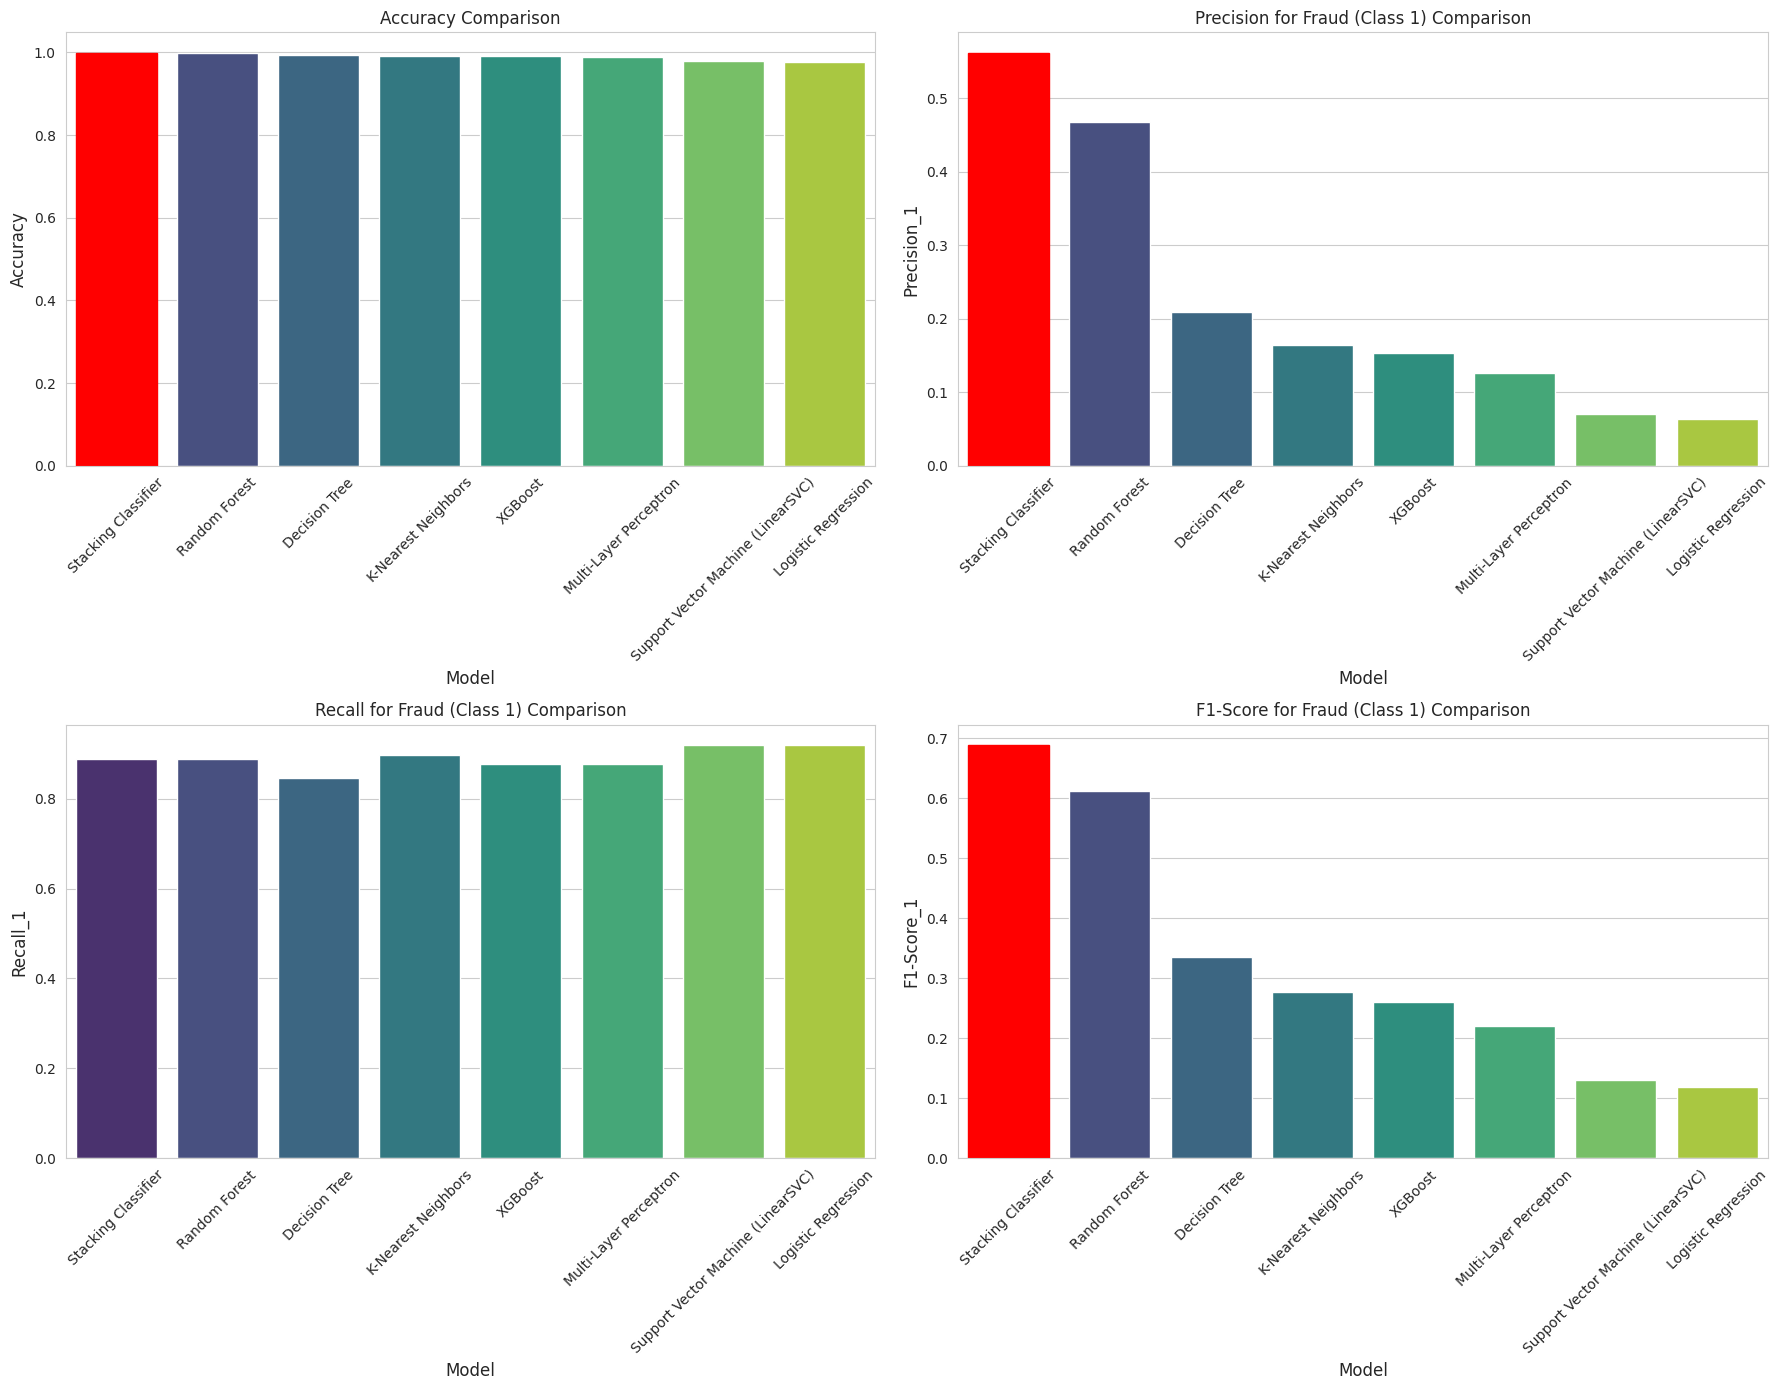

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

metrics_to_plot = {
    'Accuracy': 'Accuracy',
    'Precision for Fraud (Class 1)': 'Precision_1',
    'Recall for Fraud (Class 1)': 'Recall_1',
    'F1-Score for Fraud (Class 1)': 'F1-Score_1'
}

for i, (title, metric_col) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    sns.barplot(x='Model', y=metric_col, data=performance_df_sorted, ax=ax, palette='viridis')
    ax.set_title(f'{title} Comparison')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_col)
    ax.tick_params(axis='x', rotation=45)

    # Highlight the best model (Stacking Classifier) if it is the best for the current metric
    best_model_name = performance_df_sorted.loc[performance_df_sorted[metric_col].idxmax(), 'Model']
    if best_model_name == 'Stacking Classifier':
        bars = ax.patches
        for bar in bars:
            if bar.get_height() == performance_df_sorted[metric_col].max():
                bar.set_color('red') # Highlight best model
                break

plt.tight_layout()
plt.show()

### Confusion Matrices for All Models

Confusion matrices illustrate the performance of each classification model, showing the counts of true positive, true negative, false positive, and false negative predictions. This is crucial for understanding how well each model distinguishes between normal (0) and fraud (1) transactions.


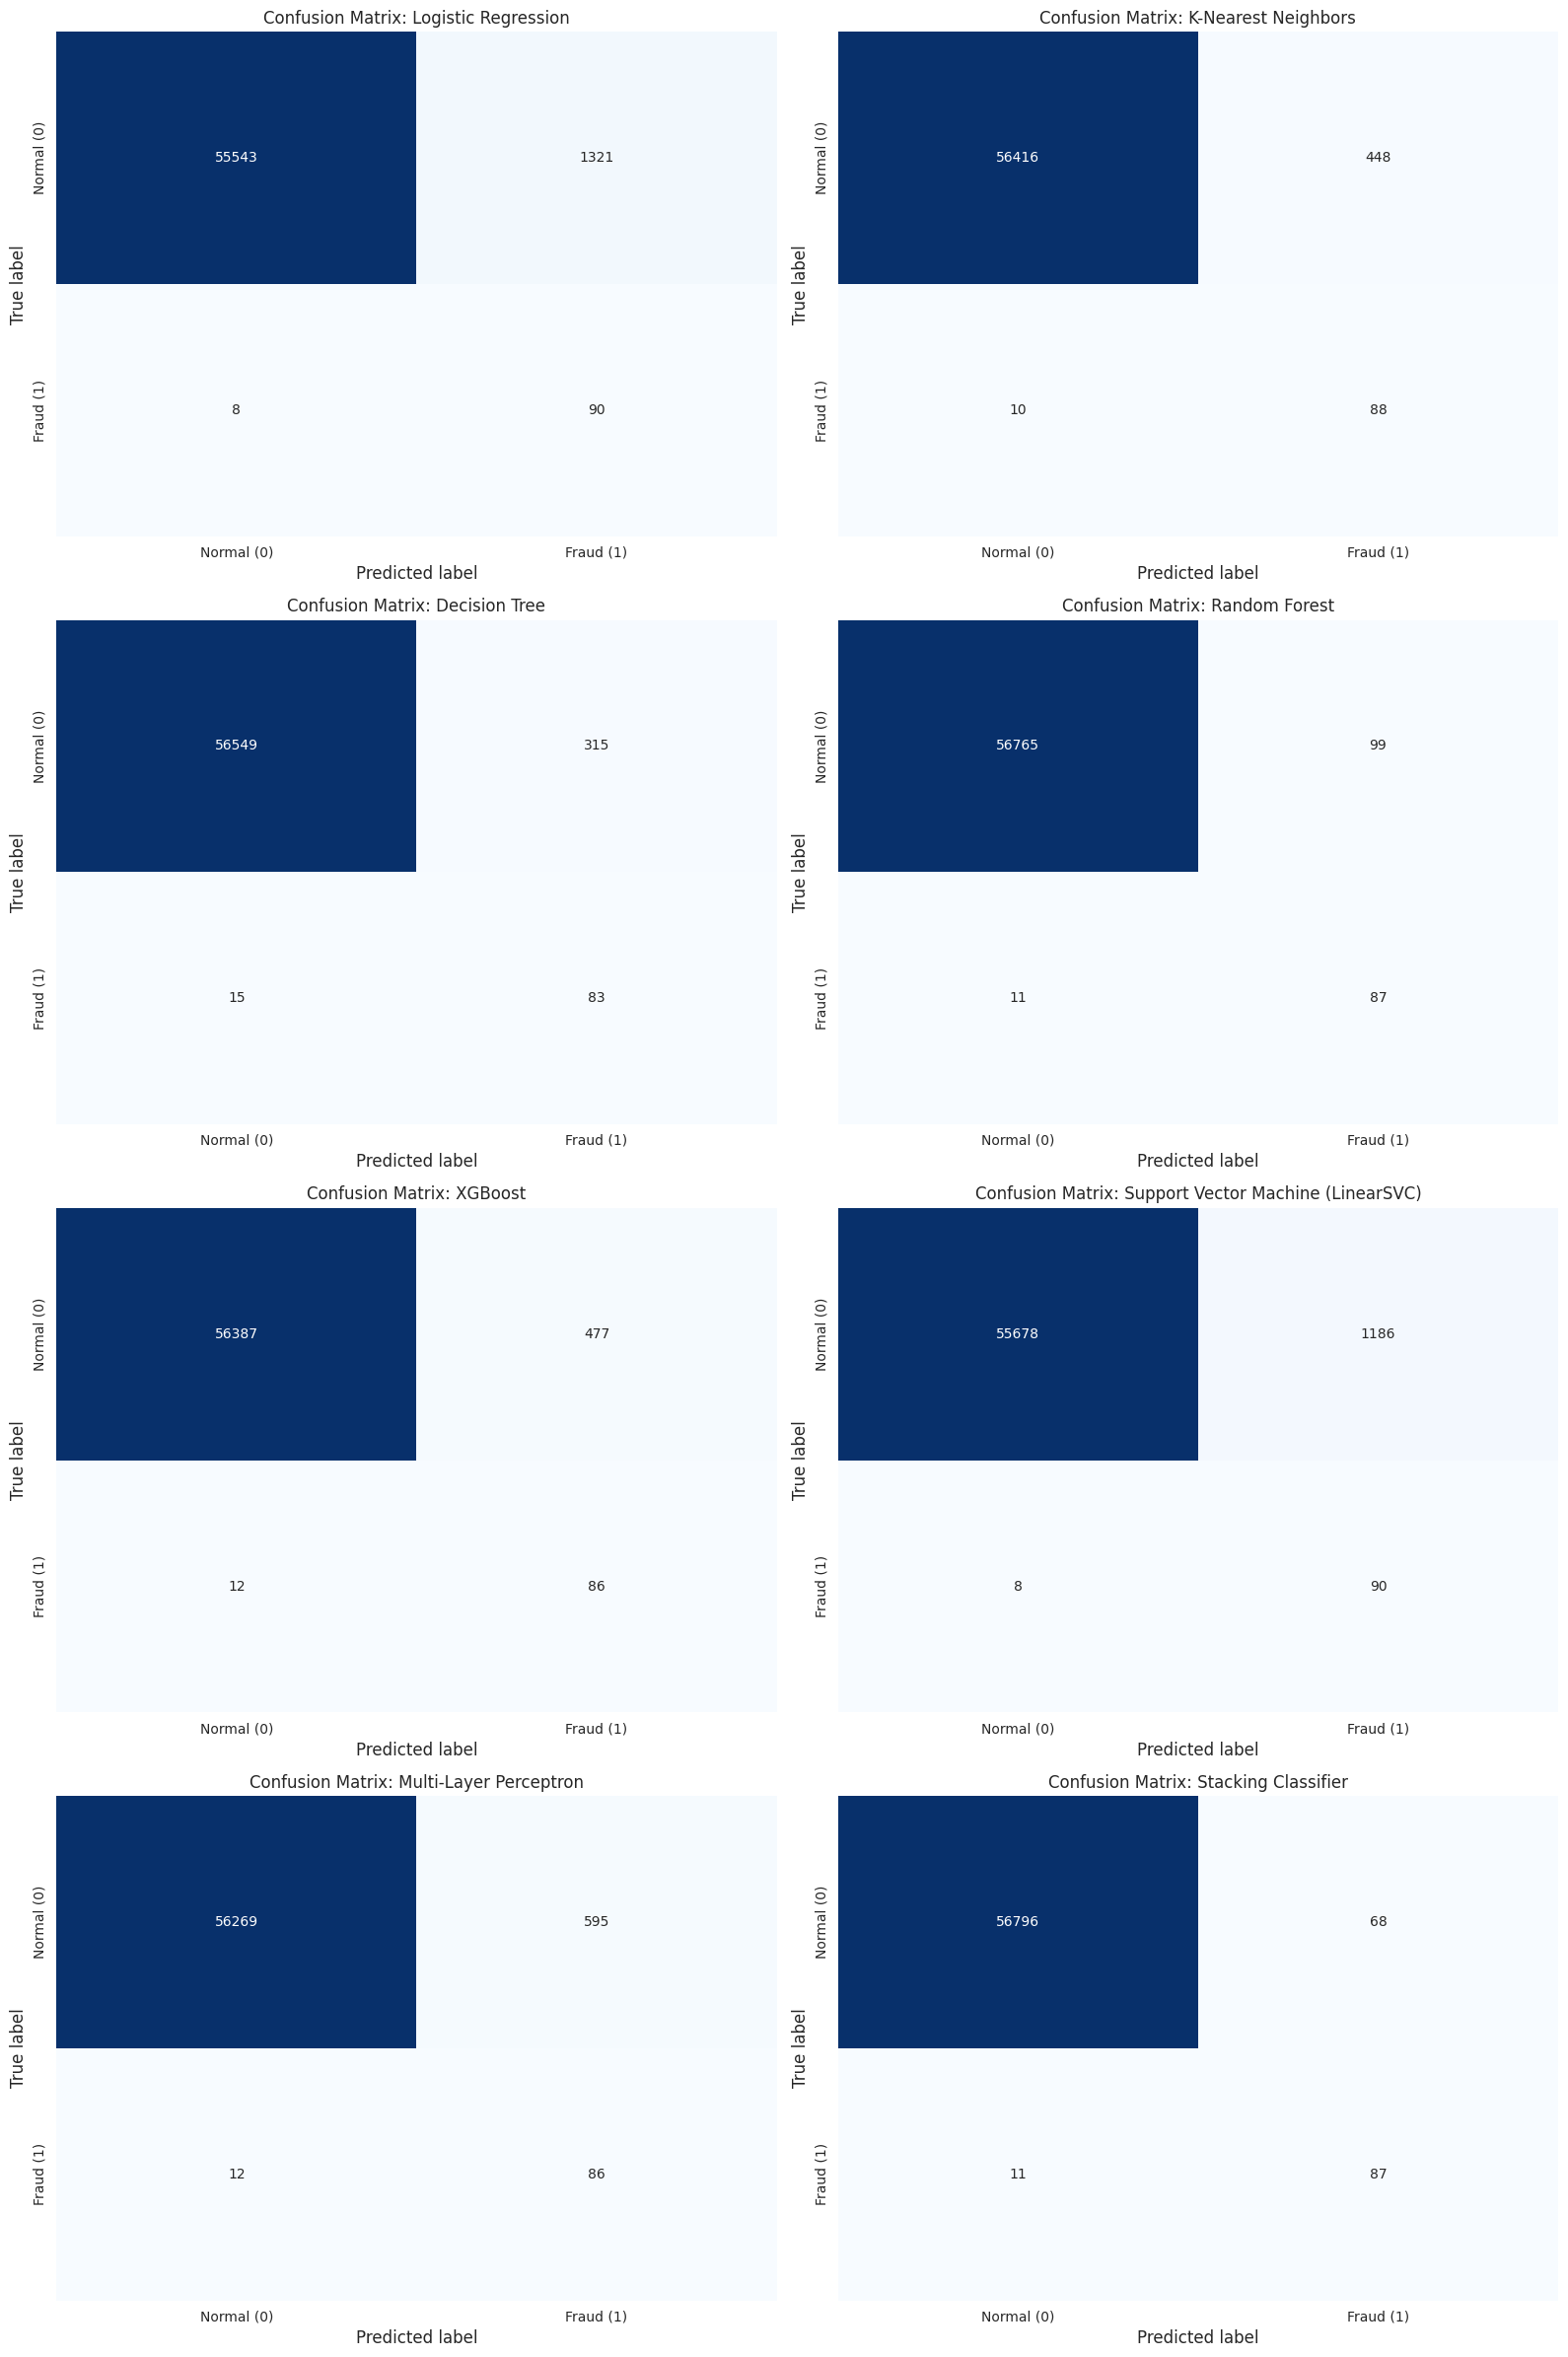

In [ ]:
models_preds = {
    'Logistic Regression': y_pred_log_reg,
    'K-Nearest Neighbors': y_pred_knn,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'Support Vector Machine (LinearSVC)': y_pred_svc,
    'Multi-Layer Perceptron': y_pred_mlp,
    'Stacking Classifier': y_pred_stack
}

fig_cm, axes_cm = plt.subplots(4, 2, figsize=(16, 24))
axes_cm = axes_cm.flatten()

for i, (model_name, y_pred) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(axes_cm[i], cm, f'Confusion Matrix: {model_name}')

plt.tight_layout()
plt.show()


### Receiver Operating Characteristic (ROC) Curves

ROC curves illustrate the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds. A higher AUC indicates a better performing model.


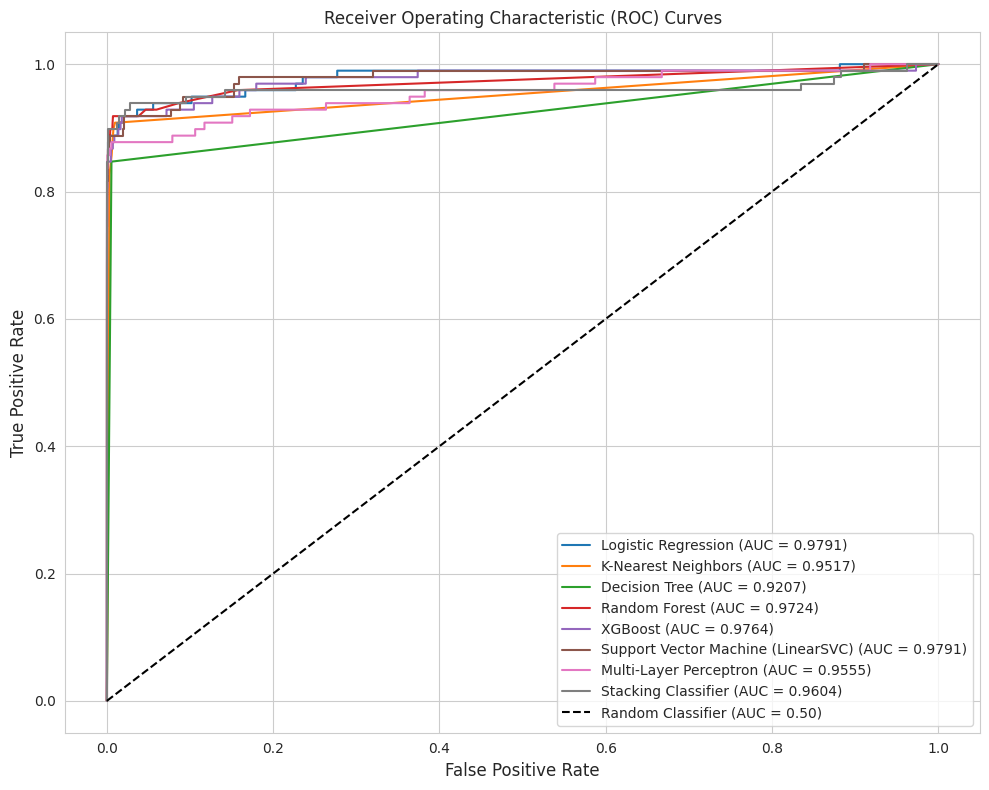

In [ ]:
models_scores = {
    'Logistic Regression': log_reg.predict_proba(X_test_pca)[:, 1],
    'K-Nearest Neighbors': knn.predict_proba(X_test_pca)[:, 1],
    'Decision Tree': dt_clf.predict_proba(X_test_pca)[:, 1],
    'Random Forest': rf_clf.predict_proba(X_test_pca)[:, 1],
    'XGBoost': xgb_clf.predict_proba(X_test_pca)[:, 1],
    'Support Vector Machine (LinearSVC)': svc_clf.decision_function(X_test_pca), # LinearSVC uses decision_function
    'Multi-Layer Perceptron': mlp_clf.predict_proba(X_test_pca)[:, 1],
    'Stacking Classifier': stack_clf.predict_proba(X_test_pca)[:, 1]
}

plt.figure(figsize=(10, 8))

for model_name, y_score in models_scores.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


### Precision-Recall Curves

Precision-Recall curves are particularly informative for imbalanced datasets, like fraud detection, where the number of negative samples far outweighs the number of positive samples. They show the trade-off between precision (the proportion of positive identifications that were actually correct) and recall (the proportion of actual positives that were identified correctly) for different thresholds. A curve closer to the top-right corner indicates better performance.


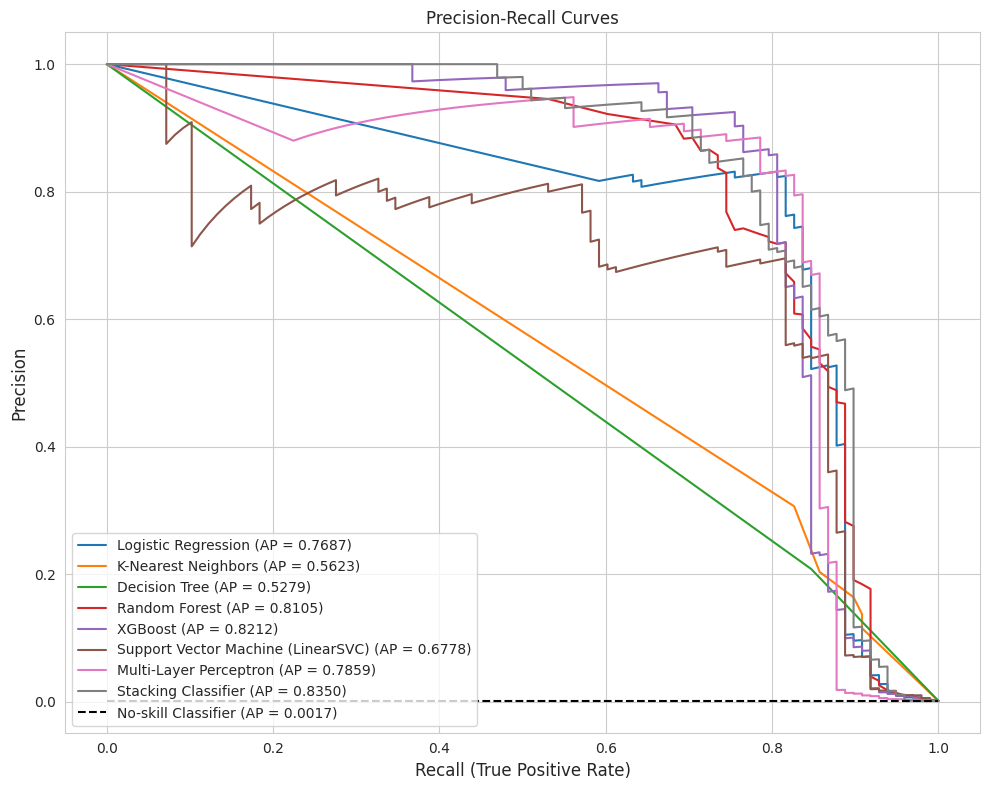

In [ ]:
plt.figure(figsize=(10, 8))

for model_name, y_score in models_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    # It is common to use average precision (AP) or AUC-PR to summarize the PR curve
    # Here we'll use auc on the curve itself, also known as Area Under PR Curve
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{model_name} (AP = {pr_auc:.4f})')

# Calculate baseline for PR curve (proportion of positive class)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], 'k--', label=f'No-skill Classifier (AP = {no_skill:.4f})')

plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


### Final Model Performance Comparison Chart (Clustered Bar Chart)

This clustered bar chart provides a focused comparison of the three most critical metrics for fraud detection (Precision_1, Recall_1, and F1-Score_1) for each model. This allows for a direct visual assessment of the trade-offs and overall effectiveness of each model in identifying the minority fraud class.


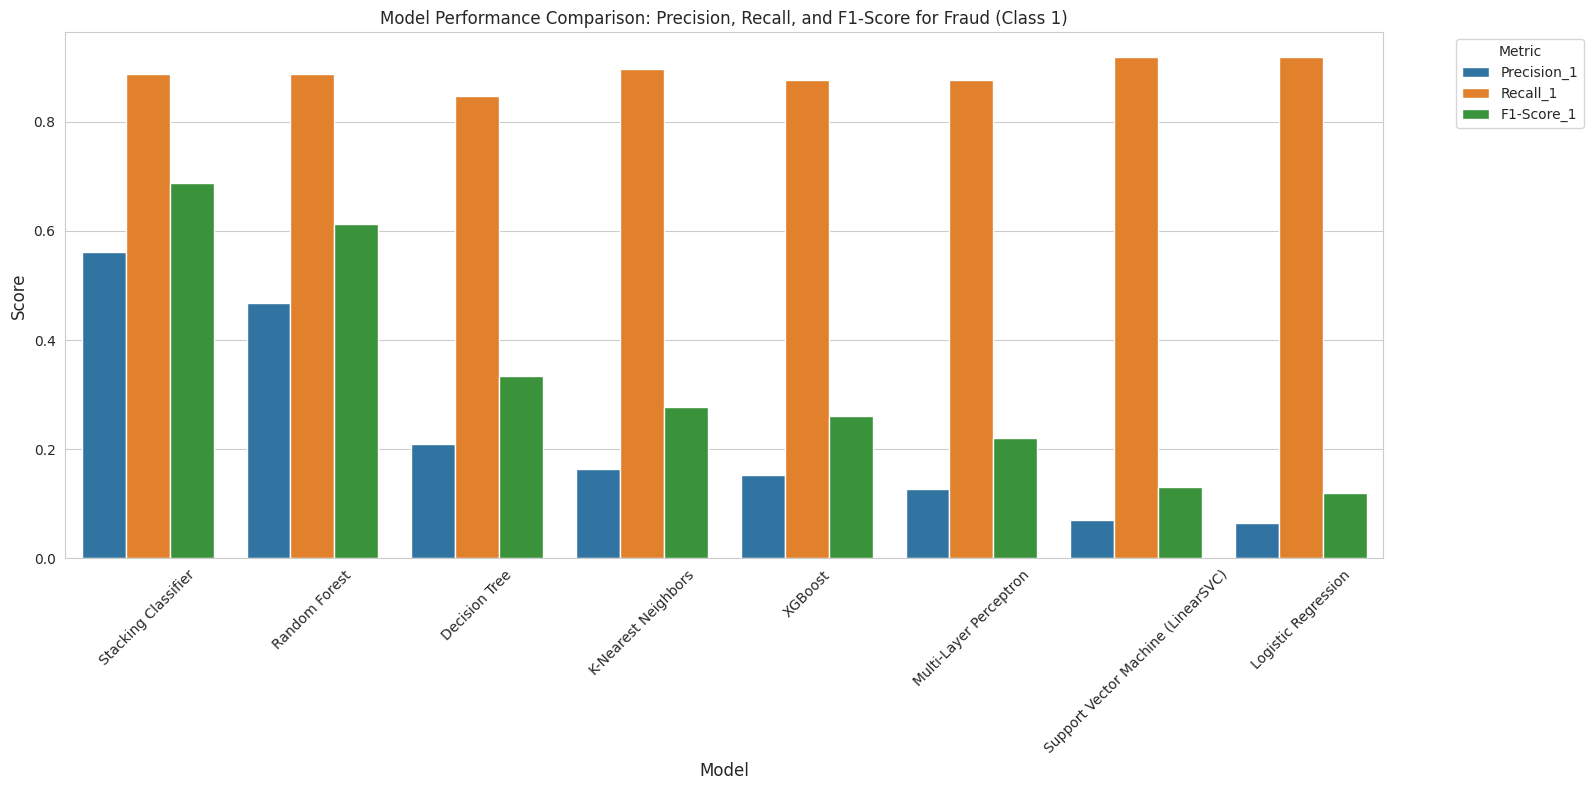

In [ ]:
metrics_for_comparison = ['Precision_1', 'Recall_1', 'F1-Score_1']

# Melt the DataFrame for easier plotting with seaborn
performance_melted = performance_df_sorted.melt(
    id_vars=['Model'],
    value_vars=metrics_for_comparison,
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(16, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=performance_melted, palette='tab10')
plt.title('Model Performance Comparison: Precision, Recall, and F1-Score for Fraud (Class 1)')
plt.xlabel('Model')
plt.ylabel('Score')
plt.tick_params(axis='x', rotation=45)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Saving Trained Models

Since runtime disconnections can cause loss of trained models, it's crucial to save them to disk. This ensures they can be reloaded later without needing to retrain them, which is especially important for deployment in a web application.

In [ ]:
import joblib
import os

# Create a directory to save models if it doesn't exist
model_dir = '/content/saved_models'
os.makedirs(model_dir, exist_ok=True)

# Dictionary of trained models
models = {
    'logistic_regression': log_reg,
    'k_nearest_neighbors': knn,
    'decision_tree': dt_clf,
    'random_forest': rf_clf,
    'xgboost': xgb_clf,
    'svc': svc_clf,
    'mlp': mlp_clf,
    'stacking_classifier': stack_clf
}

print("Saving all trained models...")
for name, model in models.items():
    filename = os.path.join(model_dir, f'{name}.joblib')
    joblib.dump(model, filename)
    print(f"Saved {name} to {filename}")

print("All models saved successfully to '/content/saved_models/'.")

# You can also save the PCA transformer and selected features, and the RobustScaler
joblib.dump(pca, os.path.join(model_dir, 'pca_transformer.joblib'))
joblib.dump(selected_features, os.path.join(model_dir, 'selected_features.joblib'))
joblib.dump(rob_scaler, os.path.join(model_dir, 'robust_scaler.joblib'))
print("PCA transformer, selected features, and RobustScaler saved.")

Saving all trained models...
Saved logistic_regression to /content/saved_models/logistic_regression.joblib
Saved k_nearest_neighbors to /content/saved_models/k_nearest_neighbors.joblib
Saved decision_tree to /content/saved_models/decision_tree.joblib
Saved random_forest to /content/saved_models/random_forest.joblib
Saved xgboost to /content/saved_models/xgboost.joblib
Saved svc to /content/saved_models/svc.joblib
Saved mlp to /content/saved_models/mlp.joblib
Saved stacking_classifier to /content/saved_models/stacking_classifier.joblib
All models saved successfully to '/content/saved_models/'.
PCA transformer, selected features, and RobustScaler saved.


In [ ]:
import shutil
import os

# Define the source directory and destination for Google Drive
source_dir = '/content/saved_models'
output_filename = 'saved_models'

# Create a zip archive of the directory
print(f"Creating zip archive of {source_dir}...")
shutil.make_archive(output_filename, 'zip', source_dir)
print(f"Zip archive '{output_filename}.zip' created.")

# Define the destination path in Google Drive
gdrive_destination_path = '/content/drive/MyDrive/saved_models.zip'

# Copy the zip file to Google Drive
print(f"Copying '{output_filename}.zip' to Google Drive at '{gdrive_destination_path}'...")
shutil.copy(f'{output_filename}.zip', gdrive_destination_path)
print("Models successfully copied to Google Drive! You can find it at MyDrive/saved_models.zip")

Creating zip archive of /content/saved_models...
Zip archive 'saved_models.zip' created.
Copying 'saved_models.zip' to Google Drive at '/content/drive/MyDrive/saved_models.zip'...
Models successfully copied to Google Drive! You can find it at MyDrive/saved_models.zip
